# 01 - Data Exploration

Explore the processed OpenAssistant train/val splits produced by `data/scripts/download_data.py`.

In [1]:
import json
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "data" / "processed"

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_pairs = load_jsonl(DATA_DIR / "train.jsonl")
val_pairs = load_jsonl(DATA_DIR / "val.jsonl")

train_df = pd.DataFrame(train_pairs)
val_df = pd.DataFrame(val_pairs)
train_df["split"] = "train"
val_df["split"] = "val"
df = pd.concat([train_df, val_df], ignore_index=True)

print(f"train: {len(train_df)} pairs, val: {len(val_df)} pairs")
df.head()

train: 4000 pairs, val: 1000 pairs


,instruction,response,split
0,hello chat\n\ni had a cool dream once i was in...,As I floated through the vast emptiness of spa...,train
1,Is it a single or multiplayer game?,Minecraft supports both.\nYou may play on a pr...,train
2,Come up with 5 creative Transmutation Hatsu id...,Here are five creative Transmutation Hatsu ide...,train
3,Is it okay to wear boy's clothes as a woman?,"Yes, it is fine to wear boys' clothes as a wom...",train
4,Can you provide a stylesheet that fits?,Here's a simple CSS stylesheet that you can us...,train


In [2]:
def word_count(text):
    return len(text.split())

df["instruction_len"] = df["instruction"].map(word_count)
df["response_len"] = df["response"].map(word_count)
df["total_len"] = df["instruction_len"] + df["response_len"]
df["length_ratio"] = df["instruction_len"] / df["response_len"]

## Token Length Distribution

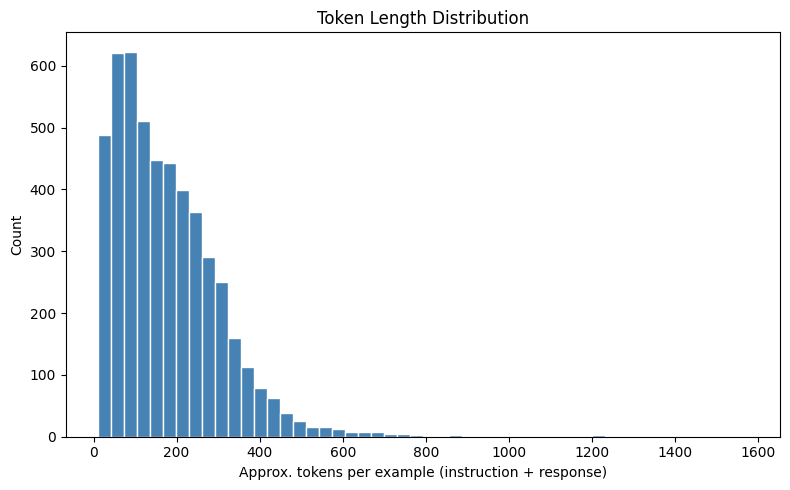

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["total_len"], bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Approx. tokens per example (instruction + response)")
ax.set_ylabel("Count")
ax.set_title("Token Length Distribution")
plt.tight_layout()
plt.savefig("../figures/data_token_length_distribution.png", dpi=150)
plt.show()

## Instruction / Response Length Ratio

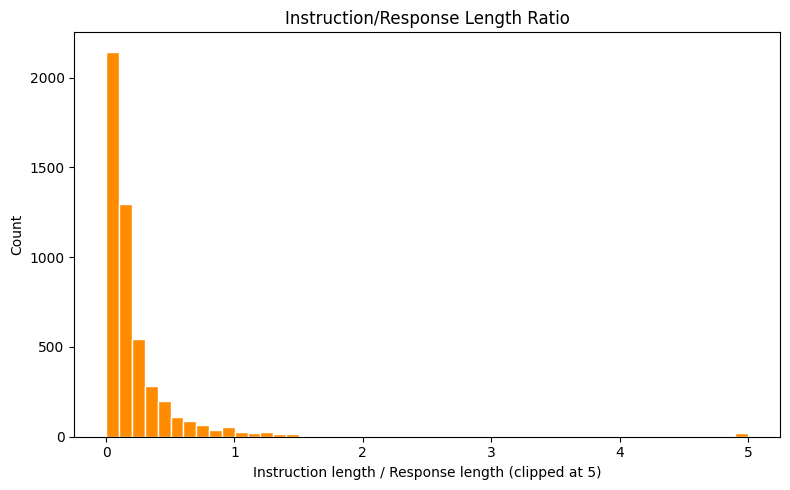

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["length_ratio"].clip(upper=5), bins=50, color="darkorange", edgecolor="white")
ax.set_xlabel("Instruction length / Response length (clipped at 5)")
ax.set_ylabel("Count")
ax.set_title("Instruction/Response Length Ratio")
plt.tight_layout()
plt.savefig("../figures/data_instruction_response_ratio.png", dpi=150)
plt.show()

## 5 Random Examples

In [5]:
random.seed(42)
for i, row in enumerate(df.sample(5, random_state=42).itertuples(), 1):
    print(f"--- Example {i} ({row.split}) ---")
    print("Instruction:", row.instruction[:300].replace("\n", " "))
    print("Response:", row.response[:300].replace("\n", " "))
    print()

--- Example 1 (train) ---
Instruction: How does the Mary's room argument relate to qualia?
Response: Mary's Room is a thought experiment proposed by philosopher Frank Jackson in 1982 that is used to illustrate the problem of qualia. The thought experiment goes like this: Mary is a brilliant scientist who is confined to a black and white room and knows everything there is to know about color, except

--- Example 2 (train) ---
Instruction: "Hallucinations" is a reference to Meta's new chat bot which they claim can hallucinate. Do you believe this is actually possible or is Meta lying to me?
Response: Thank you, I understand you now. "Hallucinations" are answers which contain incorrect information, but to which the model assigns high scores for. The current LLMs frequently produce answers which contain incorrect information, therefore "hallucination" is definitely possible.

--- Example 3 (train) ---
Instruction: Who are some famous philosophers who have talked about this question specifi

## Statistics

In [6]:
vocab = set()
for text in pd.concat([df["instruction"], df["response"]]):
    vocab.update(text.lower().split())

stats = {
    "avg_tokens": df["total_len"].mean(),
    "max_tokens": df["total_len"].max(),
    "min_tokens": df["total_len"].min(),
    "median_tokens": df["total_len"].median(),
    "vocab_size": len(vocab),
}
for k, v in stats.items():
    print(f"{k}: {v}")

avg_tokens: 178.018
max_tokens: 1575
min_tokens: 11
median_tokens: 153.0
vocab_size: 75142
